In [2]:
import os
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import numpy as np
import os


In [1]:
import scvi
print(scvi.__version__)



NameError: name 'scvi' is not defined

In [2]:
adata = sc.read_10x_h5(f'data/SC5pv2_GEX_Human_Lung_Carcinoma_DTC_filtered_feature_bc_matrix.h5')

/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
def qc(data):
    # Filter cells first
    sc.pp.filter_cells(data, min_genes=200)
    
    # Annotate genes
    data.var['mt'] = data.var_names.str.startswith('MT-')  # mitochondrial
    data.var['ribo'] = data.var_names.str.startswith(('RPS', 'RPL'))  # ribosomal
    data.var['hb'] = data.var_names.str.contains(("^HB[^(P)]"))  # hemoglobin
    
    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(data, 
                             qc_vars=['mt', 'ribo', 'hb'], 
                             inplace=True, 
                             percent_top=[20], 
                             log1p=True)
    
    # Remove unwanted columns
    remove = ['total_counts_mt', 'log1p_total_counts_mt', 
             'total_counts_ribo', 'log1p_total_counts_ribo', 
             'total_counts_hb', 'log1p_total_counts_hb']
    
    data.obs = data.obs[[x for x in data.obs.columns if x not in remove]]
    
    return data

In [4]:
adata = qc(adata)

/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
# Print some stats
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")
print(f"Median genes per cell: {np.median(adata.obs.n_genes)}")

Number of cells: 2521
Number of genes: 36601
Median genes per cell: 1489.0


In [6]:
df = pd.DataFrame(adata.obs)

In [7]:
df = df.sort_values(by='n_genes', ascending=False)

<Figure size 1000x400 with 0 Axes>

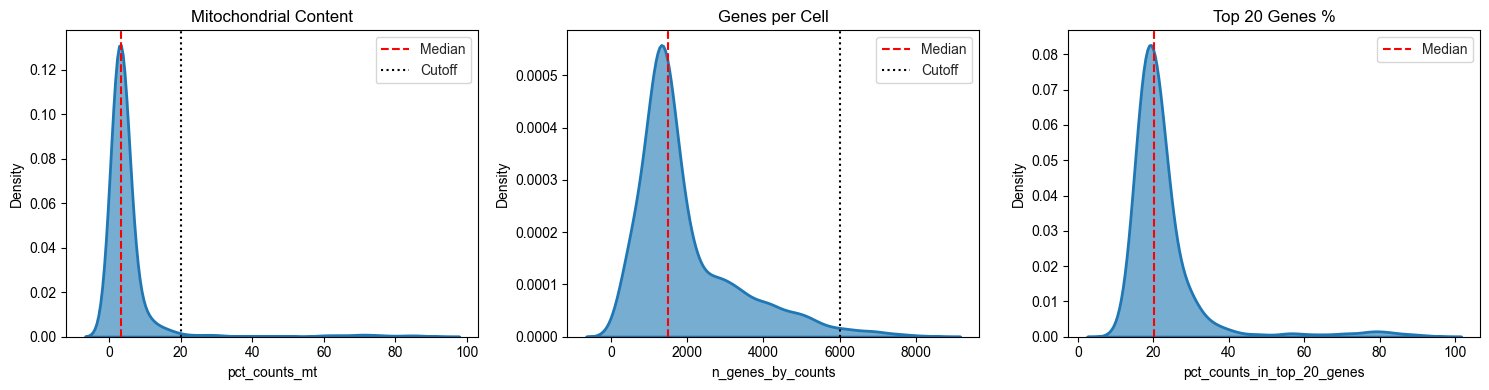


Summary Statistics:
Median MT%: 3.31
Median genes per cell: 1489
Median top 20 genes %: 20.10


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create figure
plt.figure(figsize=(10, 4))

# Plot distributions for different QC metrics
def plot_qc_dist(adata, value, title, cutoff=None):
    sns.set_style("white")
    
    # Create KDE plot
    sns.kdeplot(data=adata.obs[value], 
                fill=True, 
                alpha=0.6, 
                linewidth=2)
    
    # Add median line
    plt.axvline(x=adata.obs[value].median(), 
                color='red', 
                linestyle='--', 
                label='Median')
    
    # Add cutoff if specified
    if cutoff is not None:
        plt.axvline(x=cutoff, 
                   color='black', 
                   linestyle=':', 
                   label='Cutoff')
    
    plt.title(title)
    plt.xlabel(value)
    plt.ylabel('Density')
    plt.legend()

# Create subplots for different metrics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Plot each metric
plt.subplot(131)
plot_qc_dist(adata, 'pct_counts_mt', 'Mitochondrial Content', cutoff=20)

plt.subplot(132)
plot_qc_dist(adata, 'n_genes_by_counts', 'Genes per Cell', cutoff=6000)

plt.subplot(133)
plot_qc_dist(adata, 'pct_counts_in_top_20_genes', 'Top 20 Genes %')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Median MT%: {adata.obs['pct_counts_mt'].median():.2f}")
print(f"Median genes per cell: {adata.obs['n_genes_by_counts'].median():.0f}")
print(f"Median top 20 genes %: {adata.obs['pct_counts_in_top_20_genes'].median():.2f}")

In [9]:
import doubletdetection
from scipy.stats import median_abs_deviation as mad
import numpy as np

In [10]:
def mad_outlier(adata, metric, nmads, upper_only = False):
    M = adata.obs[metric]
    
    if not upper_only:
        return (M < np.median(M) - nmads * mad(M)) | (M > np.median(M) + nmads * mad(M))
    
    return (M > np.median(M) + nmads * mad(M))

In [11]:
import scrublet as scr
def preprocess(adata):
    adata = adata[adata.obs.pct_counts_mt < 25] #you can lower this based on the overal distribution of your dataset
    bool_vector = mad_outlier(adata, 'log1p_total_counts', 5) +\
        mad_outlier(adata, 'log1p_n_genes_by_counts', 5) +\
        mad_outlier(adata, 'pct_counts_in_top_20_genes', 5) +\
        mad_outlier(adata, 'pct_counts_mt', 3, upper_only = True)
    adata = adata[~bool_vector]

    adata.uns['cells_removed'] = sum(bool_vector)

    scrub = scr.Scrublet(adata.X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets()

    # Add results to adata
    adata.obs['doublet_scores'] = doublet_scores
    adata.obs['predicted_doublets'] = predicted_doublets
    
    # Store number of doublets and filter
    n_doublets = sum(predicted_doublets)
    print(f"Number of doublets identified: {n_doublets}")
    adata.uns['doublets_removed'] = n_doublets
    
    # Filter out doublets
    adata = adata[~adata.obs['predicted_doublets']]
    print(f"Final number of cells: {adata.n_obs}")

    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    return adata


In [12]:
adata = qc(adata)
adata = preprocess(adata)

/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/var/folders/w6/clw62qpj5t96m16fx8w7k0th0000gn/T/ipykernel_25038/3113880290.py:10: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['cells_removed'] = sum(bool_vector)
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.61
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 6.4%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.5%
Elapsed time: 2.8 seconds
Number of doublets identified: 6
Final number of cells: 2048


/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [13]:
import celltypist
from celltypist import models

In [14]:
models.get_all_models()

['Lethal_COVID19_Lung.pkl',
 'Cells_Human_Tonsil.pkl',
 'Fetal_Human_Pancreas.pkl',
 'Human_Longitudinal_Hippocampus.pkl',
 'Human_IPF_Lung.pkl',
 'Human_Lung_Atlas.pkl',
 'Mouse_Isocortex_Hippocampus.pkl',
 'Developing_Mouse_Brain.pkl',
 'Adult_Human_Skin.pkl',
 'Immune_All_High.pkl',
 'Mouse_Postnatal_DentateGyrus.pkl',
 'Adult_Human_PrefrontalCortex.pkl',
 'Cells_Lung_Airway.pkl',
 'Developing_Human_Brain.pkl',
 'Cells_Fetal_Lung.pkl',
 'Developing_Human_Organs.pkl',
 'Cells_Intestinal_Tract.pkl',
 'Developing_Human_Gonads.pkl',
 'Human_Embryonic_YolkSac.pkl',
 'Developing_Human_Thymus.pkl',
 'Fetal_Human_Pituitary.pkl',
 'Adult_Human_PancreaticIslet.pkl',
 'Developing_Human_Hippocampus.pkl',
 'Human_Placenta_Decidua.pkl',
 'Human_Developmental_Retina.pkl',
 'Adult_Mouse_Gut.pkl',
 'Healthy_Mouse_Liver.pkl',
 'Adult_Pig_Hippocampus.pkl',
 'Healthy_Adult_Heart.pkl',
 'Human_AdultAged_Hippocampus.pkl',
 'Fetal_Human_AdrenalGlands.pkl',
 'Mouse_Whole_Brain.pkl',
 'Fetal_Human_Skin.pkl'

In [15]:
lung_model = models.Model.load("Human_Lung_Atlas.pkl")

In [16]:
lung_model = models.Model.load("Human_Lung_Atlas.pkl")
predictions = celltypist.annotate(adata, model=lung_model)
adata.obs['celltypist_labels'] = predictions.predicted_labels


⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 2048 cells and 36601 genes


🔗 Matching reference genes in the model
🧬 4898 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [26]:
#ref = sc.read_h5ad('./reference_data/lung_atlas.h5ad')
def preprocess_ref(adata):
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    return adata
#preprocess_ref(ref)


In [17]:
# Print current cell type distributions
print("Cell type counts:")
print(adata.obs['celltypist_labels'].value_counts())

# Filter out cell types with too few cells (e.g., min 5 cells)
cell_counts = adata.obs['celltypist_labels'].value_counts()
keep_cells = cell_counts[cell_counts >= 5].index  # adjust number as needed

# Filter adata
print("\nBefore filtering:", adata.n_obs, "cells")
adata = adata[adata.obs['celltypist_labels'].isin(keep_cells)].copy()
print("After filtering:", adata.n_obs, "cells")

# Now proceed with analysis
sc.tl.rank_genes_groups(adata, 'celltypist_labels', method='wilcoxon')

... storing 'feature_types' as categorical
... storing 'genome' as categorical


Cell type counts:
celltypist_labels
CD8 T cells                      509
CD4 T cells                      482
B cells                          311
Monocyte-derived Mph             263
DC2                               83
Hillock-like                      74
Mast cells                        64
Basal resting                     41
Non-classical monocytes           35
NK cells                          21
AT2                               18
Classical monocytes               17
T cells proliferating             15
DC1                               12
EC venous systemic                11
Plasma cells                       9
Multiciliated (non-nasal)          8
Suprabasal                         7
Alveolar macrophages               7
Lymphatic EC mature                6
Plasmacytoid DCs                   6
pre-TB secretory                   5
Smooth muscle                      5
Interstitial Mph perivascular      5
Pericytes                          5
EC general capillary               5
EC

/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/tools/_ran

Number of highly variable genes: 2000


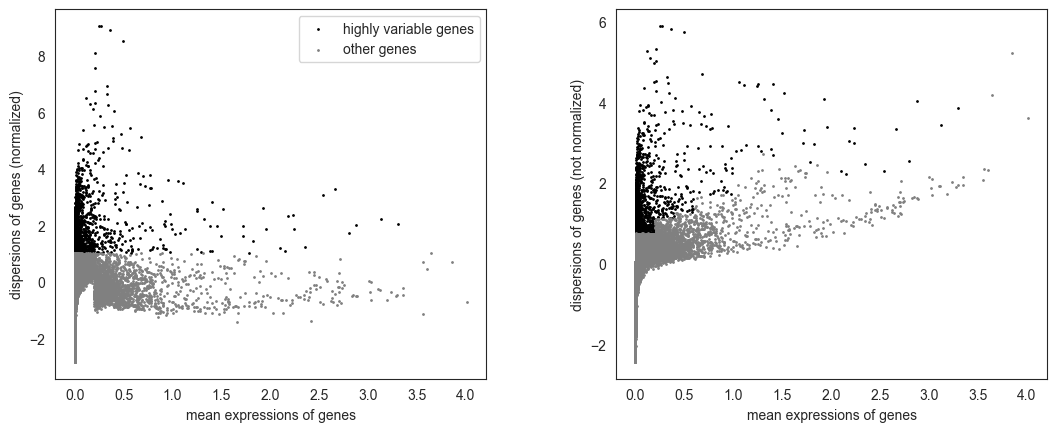

In [18]:
sc.pp.highly_variable_genes(adata, 
                          flavor='seurat', 
                          n_top_genes=2000,  # typically use 2000-4000
                          batch_key=None)    # add batch_key if you have batches

# Print number of HVGs
print(f"Number of highly variable genes: {sum(adata.var.highly_variable)}")

# Plot variable genes
sc.pl.highly_variable_genes(adata)

In [19]:
adata = adata[:, adata.var.highly_variable]

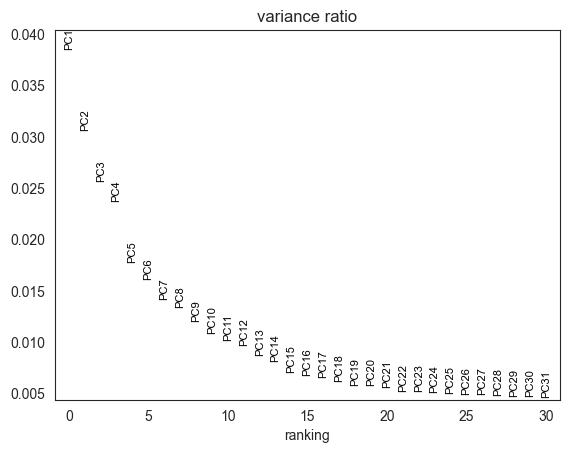

In [20]:
# Scale data
sc.pp.scale(adata)

# Run PCA
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)  # to choose n_comps

In [21]:
# Calculate neighbors
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
# UMAP
sc.tl.umap(adata)


In [22]:
sc.tl.leiden(adata, resolution=0.5)

# 4. ANALYSIS
# Find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# Differential expression
sc.tl.rank_genes_groups(adata, 'celltypist_labels', method='wilcoxon')

/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/colinpascual/Desktop/uzunlab/pipeline/lib/python3.12/site-packages/scanpy/tools/_ran

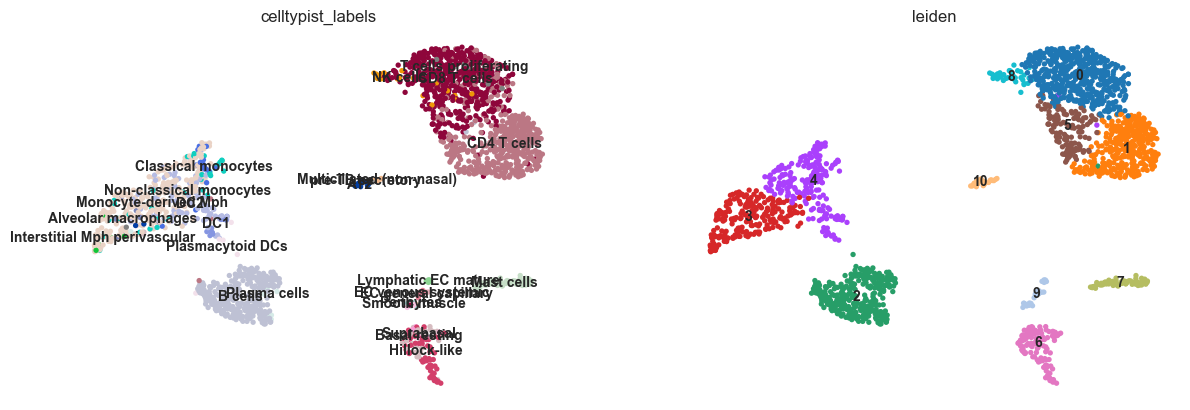

In [23]:
sc.pl.umap(adata, color=['celltypist_labels', 'leiden'], 
           legend_loc='on data',
           frameon=False)

In [26]:
overlap = pd.crosstab(adata.obs['leiden'], 
                      adata.obs['celltypist_labels'])
print("Cluster composition:")
print(overlap)

Cluster composition:
celltypist_labels  AT2  Alveolar macrophages  B cells  Basal resting  \
leiden                                                                 
0                    0                     0        0              0   
1                    0                     0        0              0   
2                    0                     0      309              0   
3                    2                     7        0              2   
4                    0                     0        0              0   
5                    0                     0        2              0   
6                    0                     0        0             39   
7                    0                     0        0              0   
8                    0                     0        0              0   
9                    0                     0        0              0   
10                  16                     0        0              0   

celltypist_labels  CD4 T cells  CD8 T cell

In [28]:
adata.obs

,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_mt,pct_counts_ribo,pct_counts_hb,doublet_scores,predicted_doublets,celltypist_labels,leiden
AAACCTGGTGGCAAAC-1,1341,1341,7.201916,2526.0,7.834788,14.726841,2.929533,19.912907,0.039588,0.039062,False,CD4 T cells,0
AAACCTGTCGCATGGC-1,1190,1190,7.082549,3122.0,8.046550,20.051249,3.619475,26.713646,0.000000,0.140584,False,CD4 T cells,1
AAACCTGTCGTACCGG-1,4857,4857,8.488382,36370.0,10.501527,30.912840,2.568051,6.604344,0.008249,0.078611,False,Monocyte-derived Mph,3
AAACGGGCACTAAGTC-1,2648,2648,7.881937,7899.0,8.974618,16.128624,2.810482,26.357767,0.000000,0.043597,False,T cells proliferating,0
AAACGGGCACTAGTAC-1,4035,4035,8.303009,16721.0,9.724481,15.824412,3.193589,14.185755,0.011961,0.336842,False,Monocyte-derived Mph,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGTGCCAGA-1,1451,1451,7.280697,3673.0,8.209036,18.486251,4.601143,25.782740,0.000000,0.057011,False,CD8 T cells,0
TTTGTCACAGGCGATA-1,599,599,6.396930,958.0,6.865891,20.041754,4.906054,22.442589,0.000000,0.057011,False,CD4 T cells,0
TTTGTCACATCACGTA-1,736,736,6.602588,1696.0,7.436617,24.587264,0.058962,37.323112,0.000000,0.171779,False,Hillock-like,6
TTTGTCATCACCGGGT-1,1756,1756,7.471363,4269.0,8.359369,18.341532,4.684938,24.877020,0.000000,0.034913,False,B cells,2


In [33]:
results = sc.get.rank_genes_groups_df(adata, group=None)  # all groups
print(results.head())

# For a specific cluster:
results_cluster0 = sc.get.rank_genes_groups_df(adata, group='0')
print("\nTop markers for cluster 0:")
print(results_cluster0.head())

  group names     scores  logfoldchanges          pvals      pvals_adj
0     0  CCL5  28.561249             NaN  2.036421e-179  4.072841e-176
1     0  CD8A  25.183077             NaN  6.139361e-140  6.139361e-137
2     0  GZMB  20.688271             NaN   4.417796e-95   2.945197e-92
3     0  NKG7  20.499460             NaN   2.176946e-93   1.088473e-90
4     0  CST7  19.848873             NaN   1.127007e-87   4.508028e-85

Top markers for cluster 0:
  names     scores  logfoldchanges          pvals      pvals_adj
0  CCL5  28.561249             NaN  2.036421e-179  4.072841e-176
1  CD8A  25.183077             NaN  6.139361e-140  6.139361e-137
2  GZMB  20.688271             NaN   4.417796e-95   2.945197e-92
3  NKG7  20.499460             NaN   2.176946e-93   1.088473e-90
4  CST7  19.848873             NaN   1.127007e-87   4.508028e-85


In [38]:
import nbconvert
nbconvert.export_script('preprocess.ipynb', 'script.py')

AttributeError: module 'nbconvert' has no attribute 'export_script'